#Walmart Superstore Sales Analysis

#Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Load Dataset

In [4]:
df=pd.read_csv('Walmart_Superstore_Sales_Analysis.csv',encoding='latin1')

#Basic Information


In [5]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,22638.48,2,0.00,41.91
1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",17499.95,3,0.00,219.58
2,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,13999.96,2,0.00,6.87
3,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,11199.97,5,0.45,-383.03
4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,10499.97,2,0.20,2.52


In [6]:
df.tail()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9981,CA-2014-110422,21-01-2014,23-01-2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,0.88,3,0.2,4.10
9982,CA-2017-121258,26-02-2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,0.85,2,0.0,15.63
9983,CA-2017-121258,26-02-2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,0.84,2,0.2,19.39
9984,CA-2017-121258,26-02-2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",0.56,4,0.0,13.32
9985,CA-2017-119914,04-05-2017,09-05-2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",0.44,2,0.0,72.95


In [7]:
df.shape

(9986, 20)

In [36]:
df.dtypes

Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [8]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9986 entries, 0 to 9985
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9986 non-null   str    
 1   Order Date     9986 non-null   str    
 2   Ship Date      9986 non-null   str    
 3   Ship Mode      9986 non-null   str    
 4   Customer ID    9986 non-null   str    
 5   Customer Name  9986 non-null   str    
 6   Segment        9986 non-null   str    
 7   Country        9986 non-null   str    
 8   City           9986 non-null   str    
 9   State          9986 non-null   str    
 10  Postal Code    9986 non-null   int64  
 11  Region         9986 non-null   str    
 12  Product ID     9986 non-null   str    
 13  Category       9986 non-null   str    
 14  Sub-Category   9986 non-null   str    
 15  Product Name   9986 non-null   str    
 16  Sales          9986 non-null   float64
 17  Quantity       9986 non-null   int64  
 18  Discount       9986

#Data Cleaning

In [10]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')
df=df.rename(columns={'sub-category':'sub_category'})

In [11]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id',
       'customer_name', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'product_id', 'category', 'sub_category', 'product_name',
       'sales', 'quantity', 'discount', 'profit'],
      dtype='str')

In [12]:
df['order_date']=pd.to_datetime(df['order_date'],dayfirst=True,errors='coerce')

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

df = df.dropna(subset=['sales', 'profit', 'order_date','sub_category'])

df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month_name()


In [13]:
df.isnull().sum()

order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
year             0
month            0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(0)

#Statistical Summary

In [14]:
df.describe()

,order_date,postal_code,sales,quantity,discount,profit,year
count,9986,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000
mean,2016-04-29 23:06:30.066092,55206.139595,229.739881,3.789305,0.156258,28.641557,2015.722111
min,2014-01-03 00:00:00,1040.000000,0.440000,1.000000,0.000000,-6599.980000,2014.000000
25%,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.730000,2015.000000
50%,2016-06-26 00:00:00,57103.000000,54.430000,3.000000,0.200000,8.640000,2016.000000
75%,2017-05-14 00:00:00,90008.000000,209.937500,5.000000,0.200000,29.355000,2017.000000
max,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.980000,2017.000000
std,NaN,32066.718706,623.348134,2.225286,0.206499,234.349230,1.123690


In [15]:
df.describe(include='all')

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,...,product_id,category,sub_category,product_name,sales,quantity,discount,profit,year,month
count,9986,9986,9986,9986,9986,9986,9986,9986,9986,9986,...,9986,9986,9986,9986,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986
unique,5009,NaN,1334,4,793,793,3,1,531,49,...,1862,3,17,1850,NaN,NaN,NaN,NaN,NaN,12
top,CA-2017-100111,NaN,16-12-2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,...,TEC-AC-10003832,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN,NaN,November
freq,14,NaN,35,5964,37,37,5189,9986,914,2001,...,18,6022,1522,48,NaN,NaN,NaN,NaN,NaN,1470
mean,NaN,2016-04-29 23:06:30.066092,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,229.739881,3.789305,0.156258,28.641557,2015.722111,NaN
min,NaN,2014-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.440000,1.000000,0.000000,-6599.980000,2014.000000,NaN
25%,NaN,2015-05-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.730000,2015.000000,NaN
50%,NaN,2016-06-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,54.430000,3.000000,0.200000,8.640000,2016.000000,NaN
75%,NaN,2017-05-14 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,209.937500,5.000000,0.200000,29.355000,2017.000000,NaN
max,NaN,2017-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.980000,2017.000000,NaN


In [16]:
df.nunique()

order_id         5009
order_date       1237
ship_date        1334
ship_mode           4
customer_id       793
customer_name     793
segment             3
country             1
city              531
state              49
postal_code       631
region              4
product_id       1862
category            3
sub_category       17
product_name     1850
sales            5453
quantity           14
discount           12
profit           5154
year                4
month              12
dtype: int64

#Business Analysis

#Sales By Region

#Profit By Segment And Region

#Profit By Year And Sub-category

#Sales and profit by year

#Sales and profit by sub-category

#Profit by sub-category

#Monthly sales trend

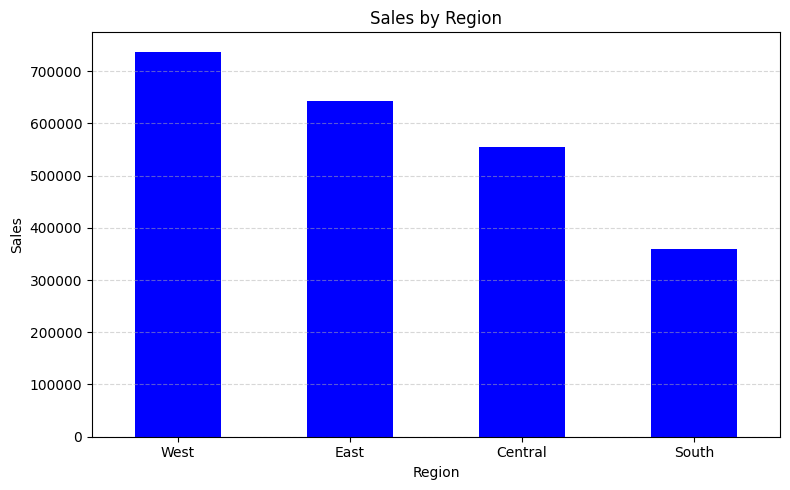

In [47]:
sales_region = df.groupby('region')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sales_region.plot(kind='bar', color='blue')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

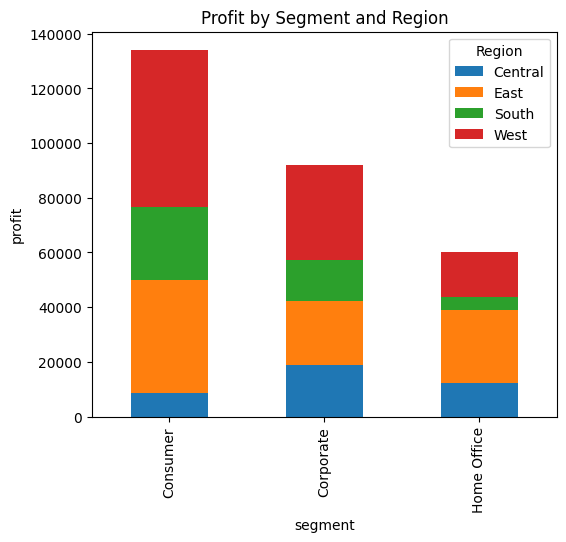

In [48]:

df_grouped=df.groupby(['segment','region'])['profit'].sum().unstack()

df_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(6,5),
)

plt.title("Profit by Segment and Region")
plt.xlabel("segment")
plt.ylabel("profit")
plt.legend(title="Region")
plt.show()

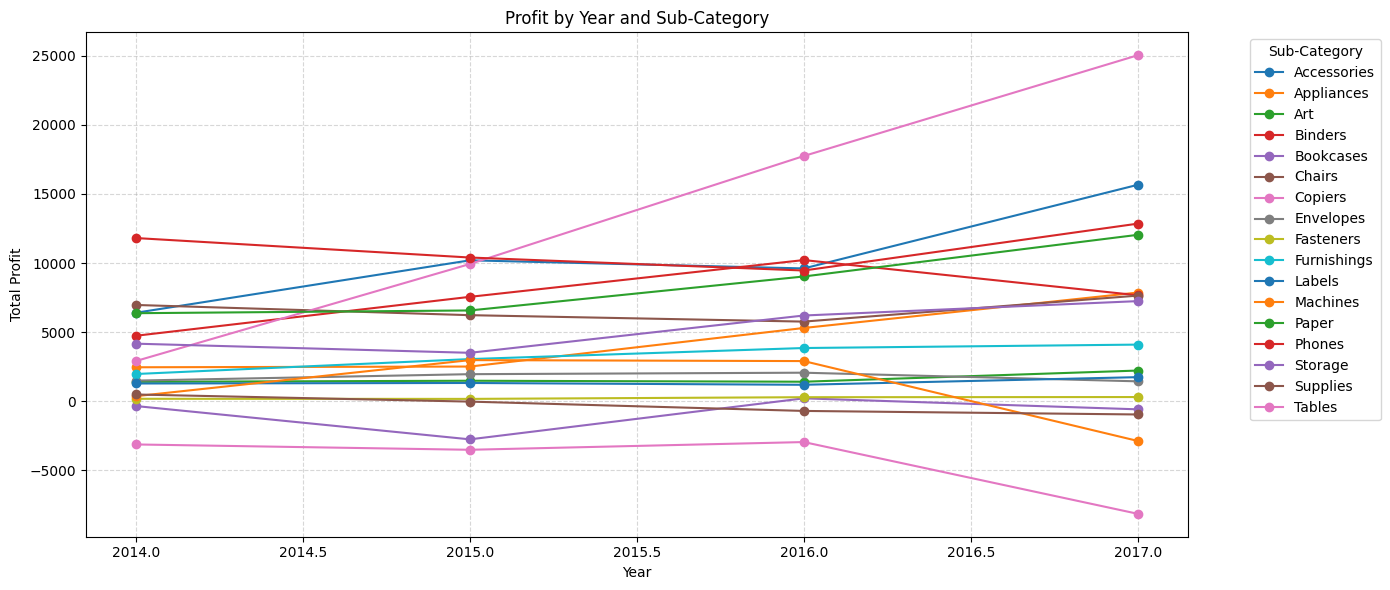

In [49]:

profit_year_sub = df.groupby(['year','sub_category'])['profit'].sum().unstack()

profit_year_sub.plot(figsize=(14,6), marker='o')

plt.title("Profit by Year and Sub-Category")
plt.xlabel("Year")
plt.ylabel("Total Profit")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Sub-Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

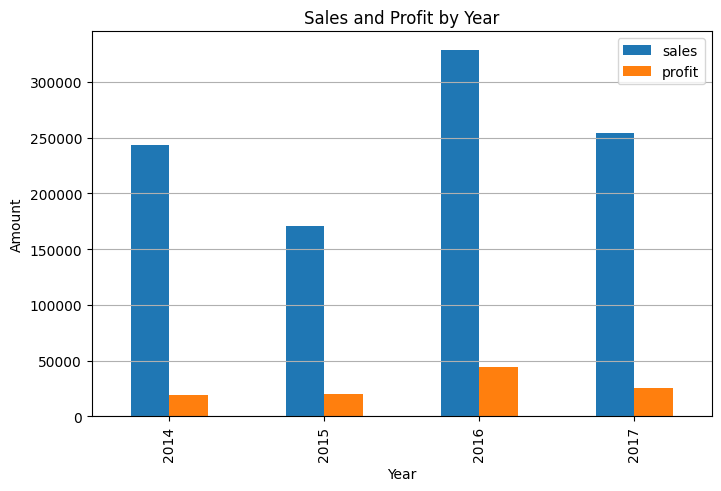

In [21]:
df_grouped=df.groupby('year')[['sales','profit']].sum()

df_grouped.plot(kind='bar',
                figsize=(8,5))
plt.title("Sales and Profit by Year")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(axis='y')
plt.show()

<Figure size 1400x600 with 0 Axes>

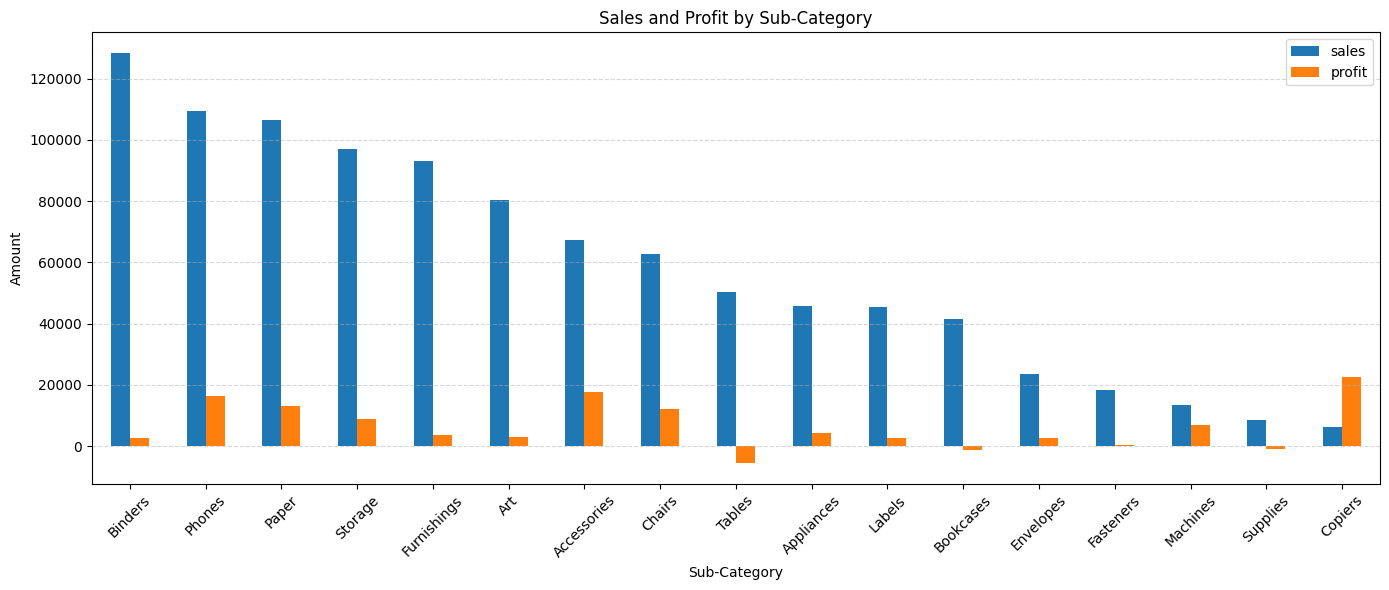

In [22]:
sub_category = df.groupby('sub_category')[['sales', 'profit']].sum().sort_values(by='sales', ascending=False)
plt.figure(figsize=(14,6))
sub_category.plot(kind='bar', figsize=(14,6))

plt.title("Sales and Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

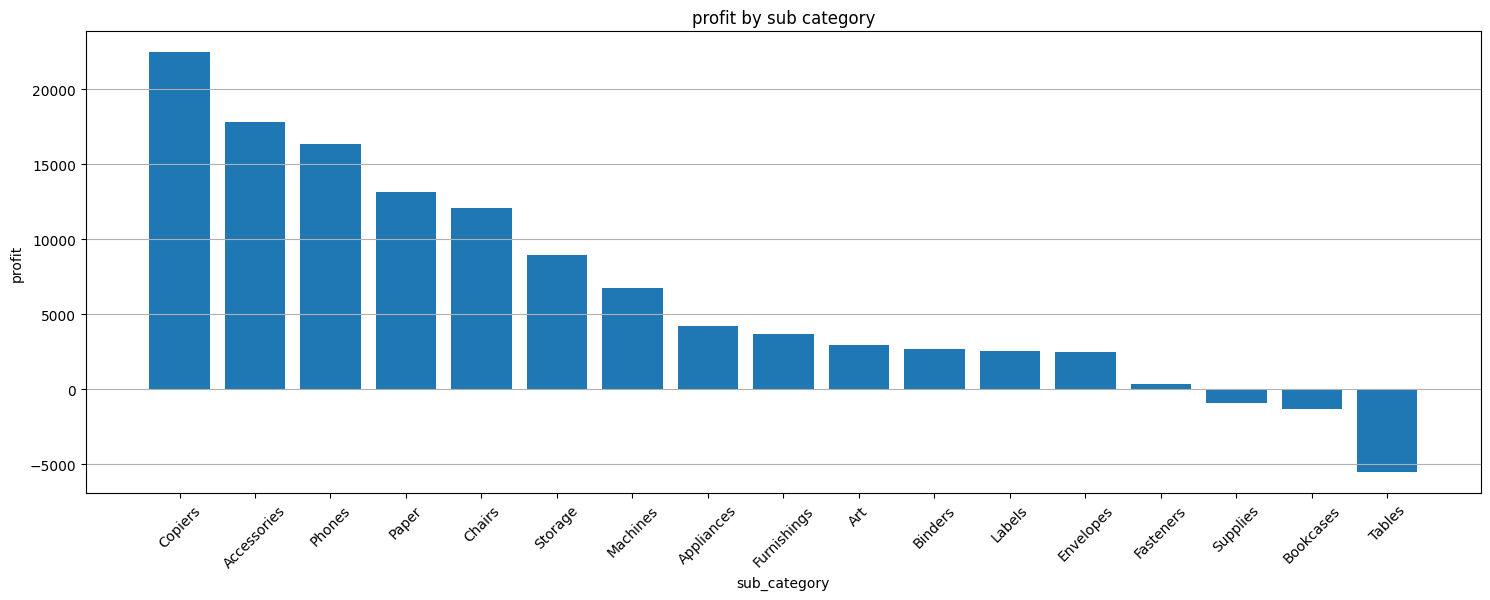

In [23]:
df_grouped=df.groupby('sub_category')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(18,6))
plt.bar(df_grouped.index,df_grouped.values)

plt.title('profit by sub category')
plt.xlabel('sub_category')
plt.ylabel('profit')

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

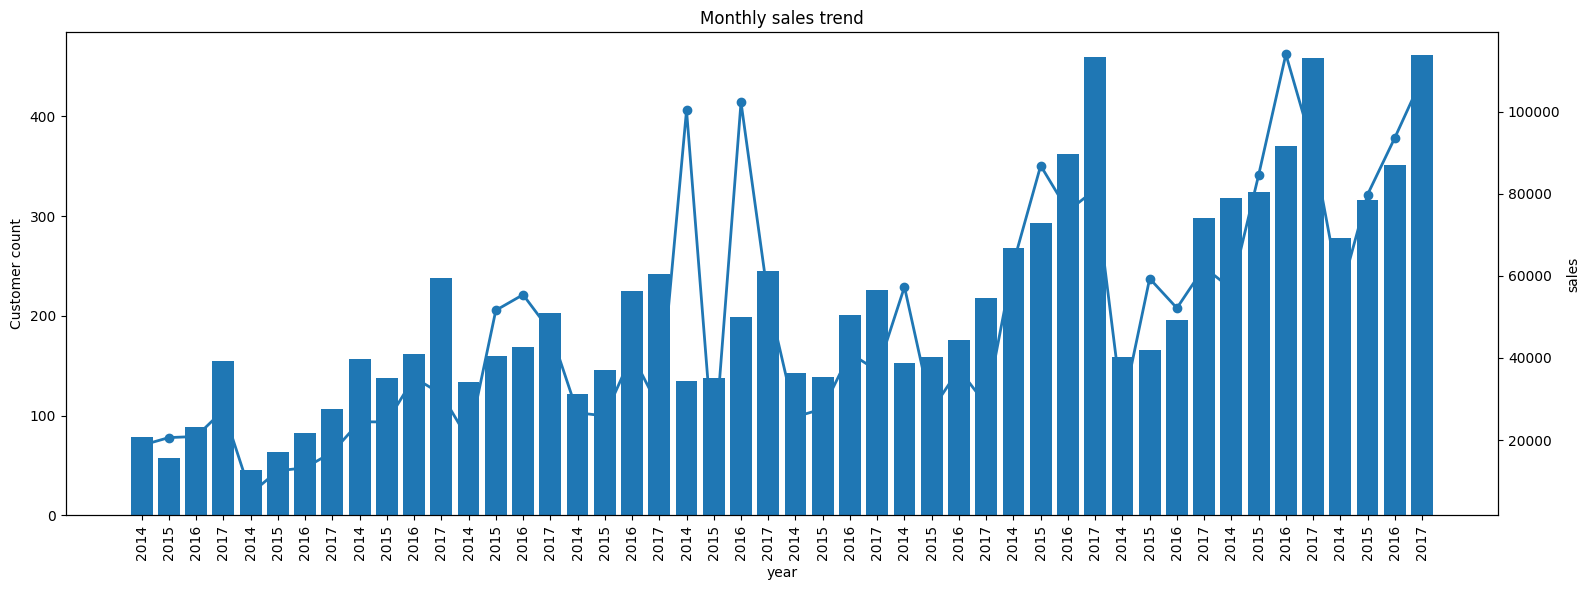

In [19]:

df['Month_num']=df['order_date'].dt.month

grouped=df.groupby(['Month_num','year']).agg({
    'customer_id':'count',
    'sales':'sum'}).reset_index()

grouped=grouped.sort_values(['Month_num','year'])
grouped['Label']=grouped['year'].astype(str)

fig,ax1=plt.subplots(figsize=(16,6))

ax1.bar(range(len(grouped)),
grouped['customer_id'],label='Count of customer id')
ax1.set_ylabel('Customer count')
ax1.set_xlabel( 'year')

ax1.set_xticks(range(len(grouped)))
ax1.set_xticklabels(grouped['Label'],rotation=90)

ax2=ax1.twinx()
ax2.plot(range(len(grouped)),
grouped['sales'],marker='o',linewidth=2,label='sum of sales')
ax2.set_ylabel('sales')

plt.title('Monthly sales trend')
plt.tight_layout()
plt.show()


#Export data to MYSQL

In [81]:
from sqlalchemy import create_engine
# my sql connection
username='root'
password='root'
host='localhost'
port='3306'
database='walmart_superstore_sales_analysis'

engine=create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

#write dataframe to mysql
table_name='superstore_data' #any table name
df.to_sql(table_name,engine,if_exists='replace',index=False)

#read back sample
pd.read_sql("select * from superstore_data limit 5",engine)

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,22638.48,2,0.00,41.91
1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",17499.95,3,0.00,219.58
2,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,13999.96,2,0.00,6.87
3,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,11199.97,5,0.45,-383.03
4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,10499.97,2,0.20,2.52
